# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- **Use Pandas to load, inspect, and clean the dataset appropriately.**
- **Transform relevant columns to create measures that address the problem at hand.**
- conduct EDA: visualization and statistical measures to systematically understand the structure of the data
- recommend a set of airplanes and makes conforming to the client's request and identify at least *two* factors contributing to airplane safety. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.

### Make relevant library imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Inspection

### Load in data from the relevant directory and inspect the dataframe.
- inspect NaNs, datatypes, and summary statistics

In [2]:
aviation_data = pd.read_csv("data/AviationData.csv", encoding="cp1252", dtype={6: str, 7: str, 28: str})

In [3]:
aviation_data.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [4]:
aviation_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

In [5]:
aviation_data.describe()

,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured
count,82805.000000,77488.000000,76379.000000,76956.000000,82977.000000
mean,1.146585,0.647855,0.279881,0.357061,5.325440
std,0.446510,5.485960,1.544084,2.235625,27.913634
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,0.000000,0.000000,0.000000,2.000000
max,8.000000,349.000000,161.000000,380.000000,699.000000


## Data Cleaning

### Filtering aircrafts and events

We want to filter the dataset to include aircraft that the client is interested in an analysis of:
- inspect relevant columns
- figure out any reasonable imputations
- filter the dataset

In [6]:
print(aviation_data['Aircraft.Category'].value_counts())
print()
print(f"Number of missing values for Aircraft.Category: {aviation_data['Aircraft.Category'].isna().sum()}" )
print( f"Percentage of missing values: {(100 * aviation_data['Aircraft.Category'].isna().sum()) / aviation_data.shape[0]}%")

Aircraft.Category
Airplane             27617
Helicopter            3440
Glider                 508
Balloon                231
Gyrocraft              173
Weight-Shift           161
Powered Parachute       91
Ultralight              30
Unknown                 14
WSFT                     9
Powered-Lift             5
Blimp                    4
UNK                      2
Rocket                   1
ULTR                     1
Name: count, dtype: int64

Number of missing values for Aircraft.Category: 56602
Percentage of missing values: 63.677170403537%


In [7]:
print(aviation_data["Amateur.Built"].value_counts())
print()
print(f"Number of missing values for Amateur.Built: {aviation_data['Amateur.Built'].isna().sum()}" )
print(f"Percentage of missing values: {(100 * aviation_data['Amateur.Built'].isna().sum()) / aviation_data.shape[0]}%")

Amateur.Built
No     80312
Yes     8475
Name: count, dtype: int64

Number of missing values for Amateur.Built: 102
Percentage of missing values: 0.1147498565626793%


In [8]:
aviation_data["Event.Date"] = pd.to_datetime(aviation_data["Event.Date"])

In [9]:
print(aviation_data["Event.Date"].describe())
print()
print(f"Number of missing values for Event.Date: {aviation_data['Event.Date'].isna().sum()}" )

count                            88889
mean     1999-09-17 17:13:39.354475904
min                1948-10-24 00:00:00
25%                1989-01-15 00:00:00
50%                1998-07-18 00:00:00
75%                2009-07-01 00:00:00
max                2022-12-29 00:00:00
Name: Event.Date, dtype: object

Number of missing values for Event.Date: 0


In [10]:
relevant_aviation_data = aviation_data[
  (aviation_data["Aircraft.Category"] == "Airplane") & # only interested in airplanes
  (aviation_data["Amateur.Built"] == "No") & # only interested in professional builds
  (aviation_data["Event.Date"] >= "1983-01-01") # Assuming today is January 1, 2023, only interested in dates >= January 1, 1983
].copy()

In [11]:
print(relevant_aviation_data["Aircraft.Category"].value_counts())
print()
print(relevant_aviation_data["Amateur.Built"].value_counts())
print()
print(relevant_aviation_data["Event.Date"].describe())
print()
print(relevant_aviation_data["Event.Date"].info())


Aircraft.Category
Airplane    21447
Name: count, dtype: int64

Amateur.Built
No    21447
Name: count, dtype: int64

count                            21447
mean     2013-10-10 16:03:05.312630784
min                1983-03-18 00:00:00
25%                2009-08-15 00:00:00
50%                2013-11-03 00:00:00
75%                2018-06-11 12:00:00
max                2022-12-26 00:00:00
Name: Event.Date, dtype: object

<class 'pandas.core.series.Series'>
Index: 21447 entries, 4149 to 88886
Series name: Event.Date
Non-Null Count  Dtype         
--------------  -----         
21447 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 335.1 KB
None


In [12]:
relevant_aviation_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21447 entries, 4149 to 88886
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Event.Id                21447 non-null  object        
 1   Investigation.Type      21447 non-null  object        
 2   Accident.Number         21447 non-null  object        
 3   Event.Date              21447 non-null  datetime64[ns]
 4   Location                21441 non-null  object        
 5   Country                 21446 non-null  object        
 6   Latitude                19169 non-null  object        
 7   Longitude               19163 non-null  object        
 8   Airport.Code            13983 non-null  object        
 9   Airport.Name            14070 non-null  object        
 10  Injury.Severity         20634 non-null  object        
 11  Aircraft.damage         20220 non-null  object        
 12  Aircraft.Category       21447 non-null  object  

### Cleaning and constructing Key Measurables

Injuries and robustness to destruction are a key interest point for the client. Clean and impute relevant columns and then create derived fields that best quantifies what the client wishes to track. **Use commenting or markdown to explain any cleaning assumptions as well as any derived columns you create.**

**Construct metric for fatal/serious injuries**

*Hint:* Estimate the total number of passengers on each flight. The likelihood of serious / fatal injury can be estimated as a fraction from this.

In [13]:
print(relevant_aviation_data[["Total.Fatal.Injuries", "Total.Serious.Injuries", "Total.Minor.Injuries", "Total.Uninjured"]].info())

<class 'pandas.core.frame.DataFrame'>
Index: 21447 entries, 4149 to 88886
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Total.Fatal.Injuries    18697 non-null  float64
 1   Total.Serious.Injuries  18619 non-null  float64
 2   Total.Minor.Injuries    18903 non-null  float64
 3   Total.Uninjured         20736 non-null  float64
dtypes: float64(4)
memory usage: 837.8 KB
None


In [14]:
column_name = "Total.Fatal.Injuries"
column_data = relevant_aviation_data[column_name]
print(column_data.value_counts())
print(f"Number of missing values for Total.Fatal.Injuries: {column_data.isna().sum()}" )
print(f"Percentage of missing values: {100 * column_data.isna().mean()}%")
print(f"Percentage of values with 0: {100 * (column_data == 0).mean()}%")
print(f"Percentage of non-missing values with 0: {100 * (column_data == 0).sum() / column_data.notna().sum()}%")
relevant_aviation_data["Total.Fatal.Injuries"].describe()


Total.Fatal.Injuries
0.0      14785
1.0       1846
2.0       1133
3.0        356
4.0        254
         ...  
112.0        1
188.0        1
41.0         1
176.0        1
132.0        1
Name: count, Length: 65, dtype: int64
Number of missing values for Total.Fatal.Injuries: 2750
Percentage of missing values: 12.822306150044296%
Percentage of values with 0: 68.93738051941996%
Percentage of non-missing values with 0: 79.07685724982618%


count    18697.000000
mean         0.740868
std          6.770638
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        295.000000
Name: Total.Fatal.Injuries, dtype: float64

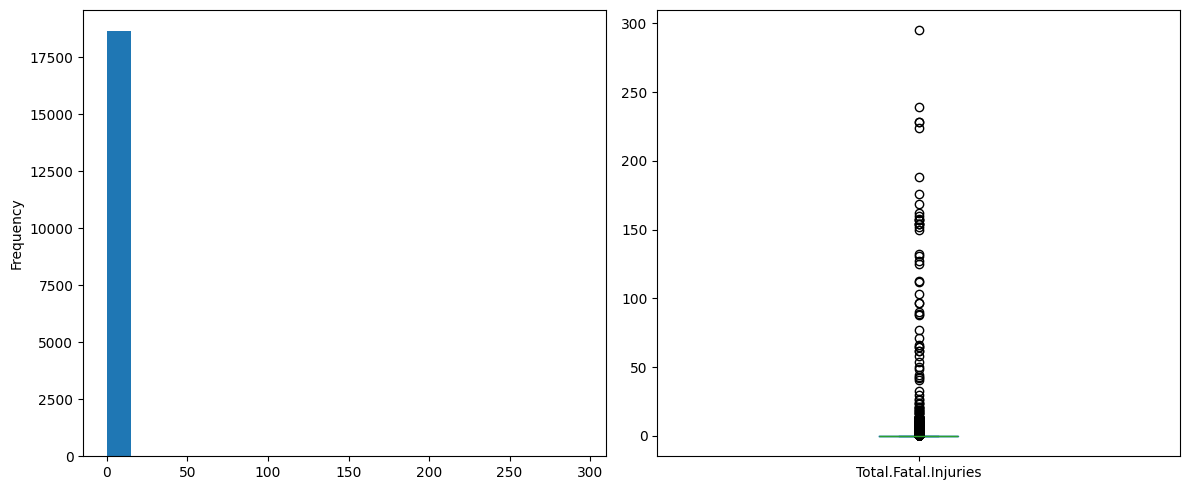

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
relevant_aviation_data["Total.Fatal.Injuries"].plot.hist(bins=20, ax=ax1)
relevant_aviation_data["Total.Fatal.Injuries"].plot.box(ax=ax2)
plt.tight_layout()
plt.show()

In [16]:
column_name = "Total.Serious.Injuries"
column_data = relevant_aviation_data[column_name]
print(column_data.value_counts())
print(f"Number of missing values for Total.Fatal.Injuries: {column_data.isna().sum()}" )
print(f"Percentage of missing values: {100 * column_data.isna().mean()}%")
print(f"Percentage of values with 0: {100 * (column_data == 0).mean()}%")
print(f"Percentage of non-missing values with 0: {100 * (column_data == 0).sum() / column_data.notna().sum()}%")
relevant_aviation_data["Total.Fatal.Injuries"].describe()

Total.Serious.Injuries
0.0      15571
1.0       1954
2.0        759
3.0        150
4.0         84
5.0         20
6.0         16
7.0         10
9.0          8
8.0          7
10.0         6
11.0         5
21.0         2
26.0         2
25.0         2
14.0         2
12.0         2
13.0         1
63.0         1
44.0         1
41.0         1
88.0         1
33.0         1
34.0         1
67.0         1
47.0         1
35.0         1
53.0         1
137.0        1
28.0         1
19.0         1
27.0         1
20.0         1
125.0        1
161.0        1
22.0         1
Name: count, dtype: int64
Number of missing values for Total.Fatal.Injuries: 2828
Percentage of missing values: 13.18599337902737%
Percentage of values with 0: 72.60222874994172%
Percentage of non-missing values with 0: 83.6296256512165%


count    18697.000000
mean         0.740868
std          6.770638
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        295.000000
Name: Total.Fatal.Injuries, dtype: float64

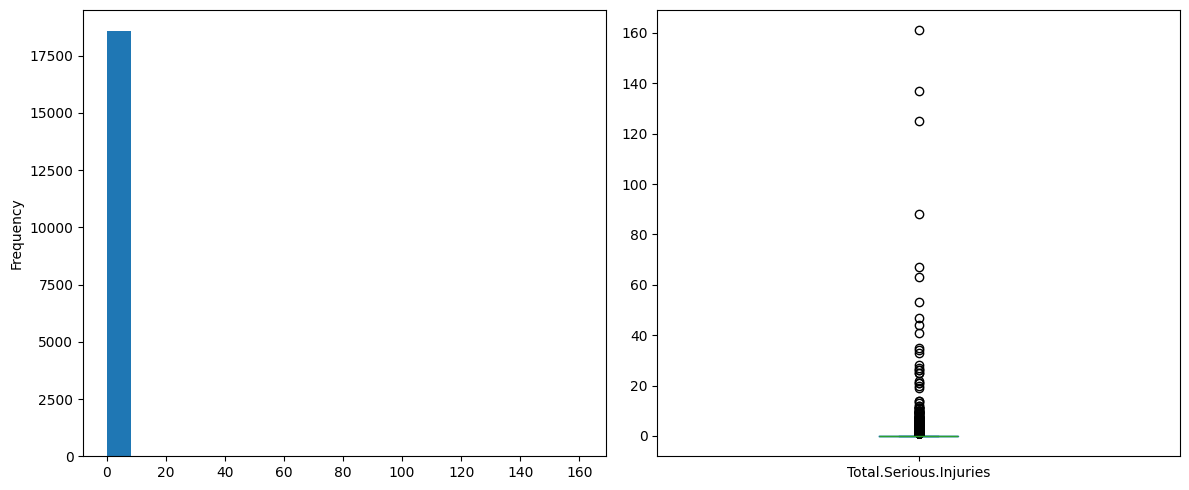

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
relevant_aviation_data["Total.Serious.Injuries"].plot.hist(bins=20, ax=ax1)
relevant_aviation_data["Total.Serious.Injuries"].plot.box(ax=ax2)
plt.tight_layout()
plt.show()

In [18]:
column_name = "Total.Minor.Injuries"
column_data = relevant_aviation_data[column_name]
print(column_data.value_counts())
print(f"Number of missing values for Total.Fatal.Injuries: {column_data.isna().sum()}" )
print(f"Percentage of missing values: {100 * column_data.isna().mean()}%")
print(f"Percentage of values with 0: {100 * (column_data == 0).mean()}%")
print(f"Percentage of non-missing values with 0: {100 * (column_data == 0).sum() / column_data.notna().sum()}%")
relevant_aviation_data["Total.Fatal.Injuries"].describe()

Total.Minor.Injuries
0.0      16248
1.0       1894
2.0        539
3.0        107
4.0         49
5.0         20
6.0         12
7.0         11
9.0          3
8.0          3
10.0         2
13.0         2
12.0         1
200.0        1
47.0         1
42.0         1
40.0         1
18.0         1
22.0         1
27.0         1
17.0         1
50.0         1
14.0         1
16.0         1
19.0         1
Name: count, dtype: int64
Number of missing values for Total.Fatal.Injuries: 2544
Percentage of missing values: 11.861798852986432%
Percentage of values with 0: 75.75884739124353%
Percentage of non-missing values with 0: 85.95461037930487%


count    18697.000000
mean         0.740868
std          6.770638
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        295.000000
Name: Total.Fatal.Injuries, dtype: float64

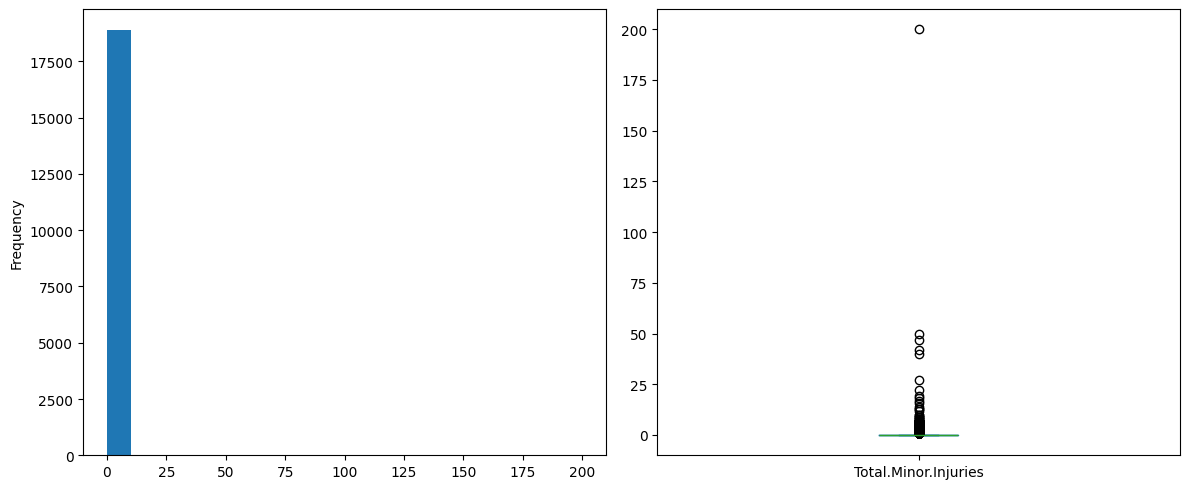

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
relevant_aviation_data["Total.Minor.Injuries"].plot.hist(bins=20, ax=ax1)
relevant_aviation_data["Total.Minor.Injuries"].plot.box(ax=ax2)
plt.tight_layout()
plt.show()

In [20]:
column_name = "Total.Uninjured"
column_data = relevant_aviation_data[column_name]
print(column_data.value_counts())
print(f"Number of missing values for Total.Fatal.Injuries: {column_data.isna().sum()}" )
print(f"Percentage of missing values: {100 * column_data.isna().mean()}%")
print(f"Percentage of values with 0: {100 * (column_data == 0).mean()}%")
print(f"Percentage of non-missing values with 0: {100 * (column_data == 0).sum() / column_data.notna().sum()}%")
print(f"Percentage of values with 1: {100 * (column_data == 1).mean()}%")
print(f"Percentage of non-missing values with 1: {100 * (column_data == 1).sum() / column_data.notna().sum()}%")
relevant_aviation_data["Total.Fatal.Injuries"].describe()


Total.Uninjured
0.0      7388
1.0      6266
2.0      4121
3.0       942
4.0       542
         ... 
239.0       1
455.0       1
237.0       1
62.0        1
206.0       1
Name: count, Length: 307, dtype: int64
Number of missing values for Total.Fatal.Injuries: 711
Percentage of missing values: 3.31514897188418%
Percentage of values with 0: 34.44770830419173%
Percentage of non-missing values with 0: 35.62885802469136%
Percentage of values with 1: 29.216207394973654%
Percentage of non-missing values with 1: 30.217978395061728%


count    18697.000000
mean         0.740868
std          6.770638
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        295.000000
Name: Total.Fatal.Injuries, dtype: float64

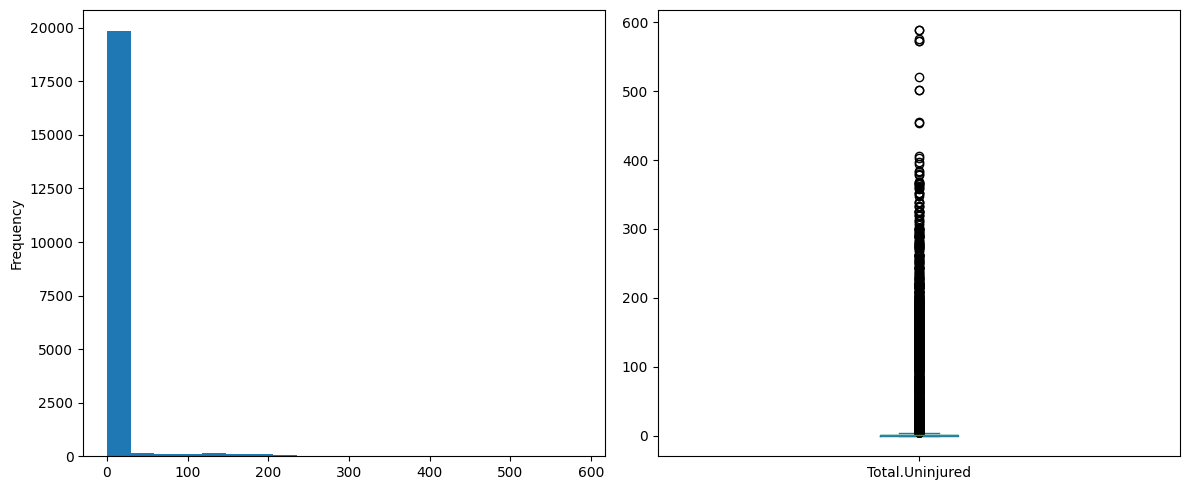

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
relevant_aviation_data["Total.Uninjured"].plot.hist(bins=20, ax=ax1)
relevant_aviation_data["Total.Uninjured"].plot.box(ax=ax2)
plt.tight_layout()
plt.show()

Since Total.Uninjured, Total.Minor.Injuries, Total.Serious.Injuries, and Total.Fatal.Injuries are all skewed right. The choice of imputation would not favor the mean over the median.

For Total.Fatal.Injuries about 13% of its values are missing. For Total.Serious.Injuries about 13% of its values are missing. For Tota.Minor.Injuries about 12% of its values are missing.For Total.Uninjured about 3.5% of its values are missing.

For Total.Fatal.Injuries, Total.Serious.Injuries, and Total.Minor.Injuries the choice of imputation is the median (which is also the mode).

However, choosing what to do with Total.Uninjured's missing values is not as simple. I could simple remove the data since the percentage is so small, but this could mean losing valid data from the other columns, depending on the correlation of missingness. So, I will impute the values. The choice is between 0 (the mode) and 1 (the median). Due to the low percentage of missing values, the median and mean be so close to each other, and the value counts for 0 and 1 are not too far apart, either the mode or the median works. I am going to go with the median here because I am more partial to the median for quantitative data, but the choice is arbitrary here for me.

In [22]:
injury_totals_column_names = ["Total.Fatal.Injuries", "Total.Serious.Injuries", "Total.Minor.Injuries", "Total.Uninjured"]
for column_name in injury_totals_column_names:
  relevant_aviation_data[column_name] = (
    relevant_aviation_data[column_name].fillna(relevant_aviation_data[column_name].median())
  )
print(relevant_aviation_data[injury_totals_column_names].info())
relevant_aviation_data[injury_totals_column_names].describe()

<class 'pandas.core.frame.DataFrame'>
Index: 21447 entries, 4149 to 88886
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Total.Fatal.Injuries    21447 non-null  float64
 1   Total.Serious.Injuries  21447 non-null  float64
 2   Total.Minor.Injuries    21447 non-null  float64
 3   Total.Uninjured         21447 non-null  float64
dtypes: float64(4)
memory usage: 837.8 KB
None


,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured
count,21447.000000,21447.000000,21447.000000,21447.000000
mean,0.645871,0.280692,0.203245,7.495640
std,6.326507,2.218737,1.647516,35.058108
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,2.000000
max,295.000000,161.000000,200.000000,588.000000


In [23]:
# Because these non-missing value columns seem like they are integers. Let's check to see if they can be converted to int safely.
print((relevant_aviation_data["Total.Fatal.Injuries"] % 1 == 0).all())
print((relevant_aviation_data["Total.Serious.Injuries"] % 1 == 0).all())
print((relevant_aviation_data["Total.Minor.Injuries"] % 1 == 0).all())
print((relevant_aviation_data["Total.Uninjured"] % 1 == 0).all())
# Because they can be safely converted to ints
relevant_aviation_data["Total.Fatal.Injuries"] = relevant_aviation_data["Total.Fatal.Injuries"].astype("int")
relevant_aviation_data["Total.Serious.Injuries"] = relevant_aviation_data["Total.Serious.Injuries"].astype("int")
relevant_aviation_data["Total.Minor.Injuries"] = relevant_aviation_data["Total.Minor.Injuries"].astype("int")
relevant_aviation_data["Total.Uninjured"] = relevant_aviation_data["Total.Uninjured"].astype("int")
print()
print(relevant_aviation_data[injury_totals_column_names].info())
relevant_aviation_data[injury_totals_column_names].head(10)

True
True
True
True

<class 'pandas.core.frame.DataFrame'>
Index: 21447 entries, 4149 to 88886
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Total.Fatal.Injuries    21447 non-null  int64
 1   Total.Serious.Injuries  21447 non-null  int64
 2   Total.Minor.Injuries    21447 non-null  int64
 3   Total.Uninjured         21447 non-null  int64
dtypes: int64(4)
memory usage: 837.8 KB
None


,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured
4149,0,0,0,588
4150,0,0,0,588
4171,1,1,0,1
4285,1,0,0,4
5957,0,0,0,289
5960,11,2,0,13
6669,1,0,0,29
6760,0,0,0,100
6806,0,0,0,1
7084,0,0,0,1


In [24]:
relevant_aviation_data["Total.number.of.passengers"] = relevant_aviation_data[injury_totals_column_names].sum(axis=1)
 # assuming that the number of passengers is derived from this sum, since there is no specific column for the number of passengers in the dataset.
relevant_aviation_data["Total.fatal.or.serious.injuries"] = relevant_aviation_data[["Total.Fatal.Injuries", "Total.Serious.Injuries"]].sum(axis=1)
relevant_aviation_data["Likelihood.of.serious.or.fatal.injury"] = relevant_aviation_data["Total.fatal.or.serious.injuries"] / relevant_aviation_data["Total.number.of.passengers"]
print(relevant_aviation_data[injury_totals_column_names + ["Total.number.of.passengers", "Total.fatal.or.serious.injuries", "Likelihood.of.serious.or.fatal.injury"]].info())
relevant_aviation_data[injury_totals_column_names + ["Total.number.of.passengers", "Total.fatal.or.serious.injuries", "Likelihood.of.serious.or.fatal.injury"]].head()

<class 'pandas.core.frame.DataFrame'>
Index: 21447 entries, 4149 to 88886
Data columns (total 7 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Total.Fatal.Injuries                   21447 non-null  int64  
 1   Total.Serious.Injuries                 21447 non-null  int64  
 2   Total.Minor.Injuries                   21447 non-null  int64  
 3   Total.Uninjured                        21447 non-null  int64  
 4   Total.number.of.passengers             21447 non-null  int64  
 5   Total.fatal.or.serious.injuries        21447 non-null  int64  
 6   Likelihood.of.serious.or.fatal.injury  20590 non-null  float64
dtypes: float64(1), int64(6)
memory usage: 1.3 MB
None


,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Total.number.of.passengers,Total.fatal.or.serious.injuries,Likelihood.of.serious.or.fatal.injury
4149,0,0,0,588,588,0,0.000000
4150,0,0,0,588,588,0,0.000000
4171,1,1,0,1,3,2,0.666667
4285,1,0,0,4,5,1,0.200000
5957,0,0,0,289,289,0,0.000000


In [25]:
relevant_aviation_data["Likelihood.of.serious.or.fatal.injury"] = relevant_aviation_data["Likelihood.of.serious.or.fatal.injury"].fillna(0)
relevant_aviation_data["Likelihood.of.serious.or.fatal.injury"].info()

<class 'pandas.core.series.Series'>
Index: 21447 entries, 4149 to 88886
Series name: Likelihood.of.serious.or.fatal.injury
Non-Null Count  Dtype  
--------------  -----  
21447 non-null  float64
dtypes: float64(1)
memory usage: 335.1 KB


**Aircraft.Damage**
- identify and execute any cleaning tasks
- construct a derived column tracking whether an aircraft was destroyed or not.

In [26]:
print(relevant_aviation_data["Aircraft.damage"].value_counts())
print()
print(f"The number of observations: {relevant_aviation_data["Aircraft.damage"].shape[0]}")
print(f"The number of missing values: {relevant_aviation_data["Aircraft.damage"].isna().sum()}")
print(f"The percentage of missing values: {100 * relevant_aviation_data["Aircraft.damage"].isna().mean()}%")
print(f"The percentage of '{relevant_aviation_data["Aircraft.damage"].mode()[0]}': {100 * (relevant_aviation_data["Aircraft.damage"] == relevant_aviation_data["Aircraft.damage"].mode()[0]).mean()}%")

Aircraft.damage
Substantial    16990
Destroyed       2316
Minor            817
Unknown           97
Name: count, dtype: int64

The number of observations: 21447
The number of missing values: 1227
The percentage of missing values: 5.721079871310673%
The percentage of 'Substantial': 79.21853872336457%


The column Aircraft.damage has 1227 are missing values, which is about 6% of its total observations. The column has 4 distinct non-explicit missing values: "Substantial" (16990 observations), "Destroyed" (2316 observations), "Minor" (817 observations), and "Unknown" (97 observations).

I am thinking that the "Unknown" value represents a missing value, and it was just given its own category. I am not sure as to what "Unknown" really means, but this my assumption. Also, the actual known missing values could be given there own category instead of imputing using the mode.

I will combine the "Unknown" values with the explicitly missing values to form a new value "Missing/Unknown.

In [27]:
relevant_aviation_data["Aircraft.damage"] = relevant_aviation_data["Aircraft.damage"].fillna("Missing/Unknown").replace("Unknown", "Missing/Unknown")
print(relevant_aviation_data["Aircraft.damage"].isna().sum())
print()
relevant_aviation_data["Aircraft.damage"].value_counts()

0



Aircraft.damage
Substantial        16990
Destroyed           2316
Missing/Unknown     1324
Minor                817
Name: count, dtype: int64

In [28]:
relevant_aviation_data["Is.aircraft.destroyed"] = (relevant_aviation_data["Aircraft.damage"] == "Destroyed")
print(relevant_aviation_data["Is.aircraft.destroyed"].value_counts())
print()
print(relevant_aviation_data["Is.aircraft.destroyed"].info())
relevant_aviation_data[["Aircraft.damage", "Is.aircraft.destroyed"]].head(10)

Is.aircraft.destroyed
False    19131
True      2316
Name: count, dtype: int64

<class 'pandas.core.series.Series'>
Index: 21447 entries, 4149 to 88886
Series name: Is.aircraft.destroyed
Non-Null Count  Dtype
--------------  -----
21447 non-null  bool 
dtypes: bool(1)
memory usage: 188.5 KB
None


,Aircraft.damage,Is.aircraft.destroyed
4149,Minor,False
4150,Minor,False
4171,Destroyed,True
4285,Missing/Unknown,False
5957,Minor,False
5960,Destroyed,True
6669,Missing/Unknown,False
6760,Minor,False
6806,Substantial,False
7084,Substantial,False


### Investigate the *Make* column
- Identify cleaning tasks here
- List cleaning tasks clearly in markdown
- Execute the cleaning tasks
- For your analysis, keep Makes with a reasonable number (you can put the threshold at 50 though lower could work as well)
  - NOTE: I am doing this part at the bottom of this notebook so that it does not disturb the analysis and exploration of the other columns.

In [29]:
print(relevant_aviation_data["Make"].value_counts())
print()
print(relevant_aviation_data["Make"].str.lower().str.strip().value_counts())
print()
print(f"The number of observations: {len(relevant_aviation_data["Make"])}")
print(f"The number of missing values: {relevant_aviation_data["Make"].isna().sum()}")
print(f"The percentage of missing values: {100 * relevant_aviation_data["Make"].isna().mean()}%")
unique_normalized_make_names = relevant_aviation_data["Make"].str.lower().str.strip()

#checking for different ways a missing value could be represented in the column
print(f"The number of observations that starts with 'missing': {unique_normalized_make_names.str.startswith('missing', na=False).sum()}")
print(f"The number of observations that starts with 'unknown': {unique_normalized_make_names.str.startswith('unknown', na=False).sum()}")
print(f"The number of observations that starts with a dash: {(unique_normalized_make_names.str.startswith("-", na=False)).sum()}")
# - could be used for negative numbers
print(f"The number of observations that are less than 2 characters: {(unique_normalized_make_names.str.len() <= 1).sum()}")
# - it is possible for a make to really have 1 character in its name, so I would just investigate the situation
print(f"The number of observations consisting of only digits: {(unique_normalized_make_names.str.isdigit()).sum()}")
# - it may be possible that make is only digits, so it would be something I would have to further investigate

Make
CESSNA            4867
PIPER             2803
Cessna            2279
Piper             1186
BOEING            1037
                  ... 
Glasair              1
Bucker               1
MERIWETHER JON       1
Grenier              1
Curtis-wright        1
Name: count, Length: 1332, dtype: int64

Make
cessna                  7146
piper                   3989
beech                   1431
boeing                  1264
mooney                   363
                        ... 
mxr technologies inc       1
easter william c           1
united consultants         1
vulcanair                  1
miller-thorp               1
Name: count, Length: 1087, dtype: int64

The number of observations: 21447
The number of missing values: 3
The percentage of missing values: 0.013987970345502867%
The number of observations that starts with 'missing': 0
The number of observations that starts with 'unknown': 1
The number of observations that starts with a dash: 0
The number of observations that are less than 

In [30]:
print(unique_normalized_make_names[unique_normalized_make_names.str.startswith('unknown', na=False)].head())
print()
print(unique_normalized_make_names[unique_normalized_make_names.fillna('').str.isdigit()].head())

63995    unknown
Name: Make, dtype: object

86009    777
88040    737
88041    737
Name: Make, dtype: object


Because the number of missing values is only 3 (which is only about 0.015% of its observations), the missing values can be dropped. However, there is a another issue. There is a difference in the value counts based on capitalization.
I assume the capitalization will not change what is the real make of the aircraft. This is a strong assumption because there is a slight possibility that two different makes can have a name that only differs in capitalization, but I am assuming that that is not case. I will use title case so that the first word of each letter is uppercased.

Just in case removing whitespace makes a difference, I added the use of the .strip() method.

I saw that there are values that go by "unknown", 777, and 737 for the Make column. 777 and 737 seem more like model names to me, so i am guessing that this is data entry error. As it is possible for 777 and 737 to mean anything, I will consider this as missing values. However, one could probably consider that "Boeing" is meant by 777 and 737, but I will not as there are only 3 values like this. It seems strange to me for a make to go by "unknown", so I will flag that as a special value to indicate missingness.

There could be other issues with the names (such punctuation or other special values to indicate a missing observation), but for now, this is enough.

Since there seems to be only 7 missing values (when including in my assumptions), I will drop them at end when I have finished looking at the other columns. Note: I drop the records at the end of the notebook.

In [31]:
invalid_aircraft_makes = ["Unknown", "777", "737"]
relevant_aviation_data["Make"] = relevant_aviation_data["Make"].str.title().replace(invalid_aircraft_makes, np.nan)
print(relevant_aviation_data["Make"].str.startswith("Unknown", na=False).sum())
print(relevant_aviation_data["Make"].str.isdigit().sum())
print()
print(relevant_aviation_data["Make"].info())
relevant_aviation_data["Make"].head(20)

0
0

<class 'pandas.core.series.Series'>
Index: 21447 entries, 4149 to 88886
Series name: Make
Non-Null Count  Dtype 
--------------  ----- 
21440 non-null  object
dtypes: object(1)
memory usage: 335.1+ KB
None


4149           Lockheed
4150             Boeing
4171              Piper
4285       De Havilland
5957            Douglas
5960           Lockheed
6669     Short Brothers
6760             Boeing
6806              Beech
7084             Cessna
7708              Beech
8585              Piper
8591           Lockheed
8865              Piper
10140        Swearingen
10247            Cessna
10605            Cessna
10688            Cessna
11638            Cessna
11898            Cessna
Name: Make, dtype: object

### Inspect Model column
- Get rid of any NaNs.
  - Note: I drop rows at the end of the notebook so that it does not disturb any analysis of other columns
- Inspect the column and counts for each model/make. Are model labels unique to each make?
- If not, create a derived column that is a unique identifier for a given plane type.

In [32]:
column_name = "Model"
column_data = relevant_aviation_data[column_name]
print(f"Number of total values: {len(column_data)}")
print(f"Number of missing values: {column_data.isna().sum()}")
print(f"% of missing values: {(100 * column_data.isna().sum()) / len(column_data)}%")
print(f"Number of unique values before lowercasing and removing leading/trailing whitespaces: {len(column_data.unique())}")
print(f"Number of unique values after lowercasing and removing leading/trailing whitespaces: {len(column_data.str.lower().str.strip().unique())}")
print(f"Number of empty/blank strings: {(column_data == '').sum()}")
print(f"% of values with the value '{column_data.mode()[0]}': {(100 * (column_data == column_data.mode()[0]).sum()) / len(column_data)}%")
print(f"% of non-missing values with the value '{column_data.mode()[0]}': {(100 * (column_data == column_data.mode()[0]).sum()) / column_data.notna().sum()}%")
print()
print(relevant_aviation_data["Model"].info())
# Because the number of missing values for Model is so low, we can remove them. I will do at the end after I
# finish looking at the other columns.
# Because there is a difference in the counts when lowercasing and removing leading/trailing, I
# preprocess the model names for this issue because I assume that casing and whitespace does not matter.
print()
relevant_aviation_data["Model"].info()


Number of total values: 21447
Number of missing values: 18
% of missing values: 0.0839278220730172%
Number of unique values before lowercasing and removing leading/trailing whitespaces: 3554
Number of unique values after lowercasing and removing leading/trailing whitespaces: 3468
Number of empty/blank strings: 0
% of values with the value '172': 3.599571035576071%
% of non-missing values with the value '172': 3.6025946147743713%

<class 'pandas.core.series.Series'>
Index: 21447 entries, 4149 to 88886
Series name: Model
Non-Null Count  Dtype 
--------------  ----- 
21429 non-null  object
dtypes: object(1)
memory usage: 335.1+ KB
None

<class 'pandas.core.series.Series'>
Index: 21447 entries, 4149 to 88886
Series name: Model
Non-Null Count  Dtype 
--------------  ----- 
21429 non-null  object
dtypes: object(1)
memory usage: 335.1+ KB


In [33]:
column_name = "Model"
relevant_aviation_data[column_name] = relevant_aviation_data[column_name].str.lower().str.strip()
column_data = relevant_aviation_data[column_name]
print(f"Number of total values: {len(column_data)}")
print(f"Number of missing values: {column_data.isna().sum()}")
print(f"% of missing values: {(100 * column_data.isna().sum()) / len(column_data)}%")
print(f"Number of unique values before lowercasing and removing leading/trailing whitespaces: {len(column_data.unique())}")
print(f"Number of unique values after lowercasing and removing leading/trailing whitespaces: {len(column_data.str.lower().str.strip().unique())}")
print(f"Number of empty/blank strings: {(column_data == '').sum()}")
print(f"% of values with the value '{column_data.mode()[0]}': {(100 * (column_data == column_data.mode()[0]).sum()) / len(column_data)}%")
print(f"% of non-missing values with the value '{column_data.mode()[0]}': {(100 * (column_data == column_data.mode()[0]).sum()) / column_data.notna().sum()}%")
print()
print(relevant_aviation_data["Model"].info())
relevant_aviation_data["Model"].head()

Number of total values: 21447
Number of missing values: 18
% of missing values: 0.0839278220730172%
Number of unique values before lowercasing and removing leading/trailing whitespaces: 3468
Number of unique values after lowercasing and removing leading/trailing whitespaces: 3468
Number of empty/blank strings: 0
% of values with the value '172': 3.599571035576071%
% of non-missing values with the value '172': 3.6025946147743713%

<class 'pandas.core.series.Series'>
Index: 21447 entries, 4149 to 88886
Series name: Model
Non-Null Count  Dtype 
--------------  ----- 
21429 non-null  object
dtypes: object(1)
memory usage: 335.1+ KB
None


4149       l-1011
4150          747
4171    pa-28-140
4285        dhc-6
5957     dc-10-10
Name: Model, dtype: object

In [34]:
relevant_aviation_data[["Model", "Make"]].groupby("Model").filter(lambda x: len(x["Make"].unique()) > 1).shape[0]
# A model's name is belonging to more than one make

8933

In [35]:
relevant_aviation_data["Make.model"] = relevant_aviation_data["Make"] + "/" + relevant_aviation_data["Model"]
print(relevant_aviation_data[["Model", "Make.model"]].groupby("Make.model").filter(lambda x: len(x["Model"].unique()) > 1).shape[0])
print(relevant_aviation_data[["Make", "Make.model"]].groupby("Make.model").filter(lambda x: len(x["Make"].unique()) > 1).shape[0])
# The Make.model column now uniquely identifies a plane


0
0


### Cleaning other columns
- there are other columns containing data that might be related to the outcome of an accident. We list a few here:
- Engine.Type
- Weather.Condition
- Number.of.Engines
- Purpose.of.flight
- Broad.phase.of.flight

Inspect and identify potential cleaning tasks in each of the above columns. Execute those cleaning tasks. 

**Note**: You do not necessarily need to impute or drop NaNs here.

In [36]:
column_name = "Engine.Type"
column_data = relevant_aviation_data[column_name]
print(column_data.info())
print()
print(column_data.value_counts())
print()
print(f"Number of total values: {len(column_data)}")
print(f"Number of missing values: {column_data.isna().sum()}")
print(f"% of missing values: {(100 * column_data.isna().sum()) / len(column_data)}%")
print(f"Number of unique values before lowercasing and removing leading/trailing whitespaces: {len(column_data.unique())}")
print(f"Number of unique values after lowercasing and removing leading/trailing whitespaces: {len(column_data.str.lower().str.strip().unique())}")
print(f"Number of empty/blank strings: {(column_data.str.strip() == '').sum()}")
print(f"% of values with the value '{column_data.mode()[0]}': {(100 * (column_data == column_data.mode()[0]).sum()) / len(column_data)}%")
print(f"% of non-missing values with the value '{column_data.mode()[0]}': {(100 * (column_data == column_data.mode()[0]).sum()) / column_data.notna().sum()}%")

<class 'pandas.core.series.Series'>
Index: 21447 entries, 4149 to 88886
Series name: Engine.Type
Non-Null Count  Dtype 
--------------  ----- 
17491 non-null  object
dtypes: object(1)
memory usage: 335.1+ KB
None

Engine.Type
Reciprocating      15015
Turbo Prop          1251
Turbo Fan            929
Unknown              134
Turbo Jet            133
Geared Turbofan       12
Turbo Shaft           11
Electric               5
UNK                    1
Name: count, dtype: int64

Number of total values: 21447
Number of missing values: 3956
% of missing values: 18.445470228936447%
Number of unique values before lowercasing and removing leading/trailing whitespaces: 10
Number of unique values after lowercasing and removing leading/trailing whitespaces: 10
Number of empty/blank strings: 0
% of values with the value 'Reciprocating': 70.00979157924185%
% of non-missing values with the value 'Reciprocating': 85.84414841918701%


In [37]:
column_name = "Weather.Condition"
column_data = relevant_aviation_data[column_name]
print(column_data.info())
print()
print(column_data.value_counts())
print()
print(f"Number of total values: {len(column_data)}")
print(f"Number of missing values: {column_data.isna().sum()}")
print(f"% of missing values: {(100 * column_data.isna().sum()) / len(column_data)}%")
print(f"Number of unique values before lowercasing and removing leading/trailing whitespaces: {len(column_data.unique())}")
print(f"Number of unique values after lowercasing and removing leading/trailing whitespaces: {len(column_data.str.lower().str.strip().unique())}")
print(f"Number of empty/blank strings: {(column_data.str.strip() == '').sum()}")
print(f"% of values with the value '{column_data.mode()[0]}': {(100 * (column_data == column_data.mode()[0]).sum()) / len(column_data)}%")
print(f"% of non-missing values with the value '{column_data.mode()[0]}': {(100 * (column_data == column_data.mode()[0]).sum()) / column_data.notna().sum()}%")

<class 'pandas.core.series.Series'>
Index: 21447 entries, 4149 to 88886
Series name: Weather.Condition
Non-Null Count  Dtype 
--------------  ----- 
18468 non-null  object
dtypes: object(1)
memory usage: 335.1+ KB
None

Weather.Condition
VMC    17089
IMC     1069
Unk      215
UNK       95
Name: count, dtype: int64

Number of total values: 21447
Number of missing values: 2979
% of missing values: 13.890054553084347%
Number of unique values before lowercasing and removing leading/trailing whitespaces: 5
Number of unique values after lowercasing and removing leading/trailing whitespaces: 4
Number of empty/blank strings: 0
% of values with the value 'VMC': 79.68014174476617%
% of non-missing values with the value 'VMC': 92.53303010612952%


In [38]:
column_name = "Number.of.Engines"
column_data = relevant_aviation_data[column_name]
print(column_data.info())
print()
print(column_data.value_counts())
print()
print(f"Number of total values: {len(column_data)}")
print(f"Number of missing values: {column_data.isna().sum()}")
print(f"% of missing values: {(100 * column_data.isna().sum()) / len(column_data)}%")
print(f"% of values with the value '{column_data.median()}': {(100 * (column_data == column_data.median()).sum()) / len(column_data)}%")
print(f"% of non-missing values with the value '{column_data.median()}': {(100 * (column_data == column_data.median()).sum()) / column_data.notna().sum()}%")
column_data.describe()


<class 'pandas.core.series.Series'>
Index: 21447 entries, 4149 to 88886
Series name: Number.of.Engines
Non-Null Count  Dtype  
--------------  -----  
18896 non-null  float64
dtypes: float64(1)
memory usage: 335.1 KB
None

Number.of.Engines
1.0    15742
2.0     3010
4.0       93
3.0       40
0.0        9
8.0        1
6.0        1
Name: count, dtype: int64

Number of total values: 21447
Number of missing values: 2551
% of missing values: 11.894437450459272%
% of values with the value '1.0': 73.39954305963538%
% of non-missing values with the value '1.0': 83.30863674851821%


count    18896.000000
mean         1.178450
std          0.429666
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: Number.of.Engines, dtype: float64

In [39]:
column_name = "Purpose.of.flight"
column_data = relevant_aviation_data[column_name]
print(column_data.info())
print()
print(column_data.value_counts())
print()
print(f"Number of total values: {len(column_data)}")
print(f"Number of missing values: {column_data.isna().sum()}")
print(f"% of missing values: {(100 * column_data.isna().sum()) / len(column_data)}%")
print(f"Number of unique values before lowercasing and removing leading/trailing whitespaces: {len(column_data.unique())}")
print(f"Number of unique values after lowercasing and removing leading/trailing whitespaces: {len(column_data.str.lower().str.strip().unique())}")
print(f"Number of empty/blank strings: {(column_data.str.strip() == '').sum()}")
print(f"% of values with the value '{column_data.mode()[0]}': {(100 * (column_data == column_data.mode()[0]).sum()) / len(column_data)}%")
print(f"% of non-missing values with the value '{column_data.mode()[0]}': {(100 * (column_data == column_data.mode()[0]).sum()) / column_data.notna().sum()}%")


<class 'pandas.core.series.Series'>
Index: 21447 entries, 4149 to 88886
Series name: Purpose.of.flight
Non-Null Count  Dtype 
--------------  ----- 
17767 non-null  object
dtypes: object(1)
memory usage: 335.1+ KB
None

Purpose.of.flight
Personal                     11714
Instructional                 2753
Aerial Application             935
Business                       499
Unknown                        378
Positioning                    350
Skydiving                      164
Aerial Observation             161
Other Work Use                 155
Flight Test                    120
Ferry                          103
Executive/corporate            103
Banner Tow                      89
Public Aircraft - Federal       52
Air Race show                   48
Public Aircraft                 39
Glider Tow                      35
Public Aircraft - State         24
Firefighting                    17
Public Aircraft - Local         12
ASHO                             5
Air Race/show              

In [40]:
column_name = "Broad.phase.of.flight"
column_data = relevant_aviation_data[column_name]
print(column_data.info())
print()
print(column_data.value_counts())
print()
print(f"Number of total values: {len(column_data)}")
print(f"Number of missing values: {column_data.isna().sum()}")
print(f"% of missing values: {(100 * column_data.isna().sum()) / len(column_data)}%")
print(f"Number of unique values before lowercasing and removing leading/trailing whitespaces: {len(column_data.unique())}")
print(f"Number of unique values after lowercasing and removing leading/trailing whitespaces: {len(column_data.str.lower().str.strip().unique())}")
print(f"Number of empty/blank strings: {(column_data.str.strip() == '').sum()}")
print(f"% of values with the value '{column_data.mode()[0]}': {(100 * (column_data == column_data.mode()[0]).sum()) / len(column_data)}%")
print(f"% of non-missing values with the value '{column_data.mode()[0]}': {(100 * (column_data == column_data.mode()[0]).sum()) / column_data.notna().sum()}%")

<class 'pandas.core.series.Series'>
Index: 21447 entries, 4149 to 88886
Series name: Broad.phase.of.flight
Non-Null Count  Dtype 
--------------  ----- 
2828 non-null   object
dtypes: object(1)
memory usage: 335.1+ KB
None

Broad.phase.of.flight
Landing        1255
Takeoff         509
Cruise          266
Approach        234
Maneuvering     169
Taxi            111
Go-around        89
Descent          73
Climb            60
Standing         47
Unknown          12
Other             3
Name: count, dtype: int64

Number of total values: 21447
Number of missing values: 18619
% of missing values: 86.81400662097263%
Number of unique values before lowercasing and removing leading/trailing whitespaces: 13
Number of unique values after lowercasing and removing leading/trailing whitespaces: 13
Number of empty/blank strings: 0
% of values with the value 'Landing': 5.851634261202033%
% of non-missing values with the value 'Landing': 44.37765205091938%


For Engine.Type, about 18.5% of values are missing, and the mode ("Reciprocating") makes up about 70% of total values. I could impute the missing values with the mode, but because there is an "Unknown" value, I will combine the missing values with the "Unknown" value to form a new "Missing/Unknown" value.

For Weather.Condition, about 14% of values are missing, and the mode ("VMC") makes up about about 80% of total values. Because the mode is dominant, I will impute the missing values with the mode and create new indicator column of missingness because it could be useful to know whether the value was missing at some point give that about 14% of the values are missing. I do notice that there is a casing issue with "Unk" and "UNK" values, so I will normalize this by coverting both to "UNK".

For Number.of.Engines, about 12% of values are missing, and the mean and mode is 1. The mean is about 1.18. I am not using the mean because the column values are skewed right. I will impute the missing values with 1. The value 1 takes about 73.5% of all values. I do notice that the type is a float and it should be converted into an int.

For Purpose.of.flight, about 17% of values are missing, and the mode ("Personal") makes up about 55% of all values. I could impute the missing values with the mode, but because ther is an "Unknown" value, I will combine the missing values with the "Unknown" value to form a new "Missing/Unknown" value.

For Broad.phase.of.light, about 87% of values are missing, and the mode ("Landing") makes up about 6% of all values. Rather than combine missing values with the "Unknown" to create a new value, I think that it is best to just drop the column because there are too many missing values.

In [41]:
relevant_aviation_data["Engine.Type"] = relevant_aviation_data["Engine.Type"].fillna("Missing/Unknown").replace("Unknown", "Missing/Unknown")
relevant_aviation_data["Weather.Condition"] = relevant_aviation_data["Weather.Condition"].replace("Unk", "UNK").fillna("VMC")
relevant_aviation_data["Weather.Condition.missingness"] = relevant_aviation_data["Weather.Condition"].isna()
relevant_aviation_data["Number.of.Engines"] = relevant_aviation_data["Number.of.Engines"].fillna(1).astype("int")
relevant_aviation_data["Purpose.of.flight"] = relevant_aviation_data["Purpose.of.flight"].fillna("Missing/Unknown").replace("Unknown", "Missing/Unknown")
relevant_aviation_data[["Engine.Type", "Weather.Condition", "Weather.Condition.missingness", "Number.of.Engines", "Purpose.of.flight"]].info()


<class 'pandas.core.frame.DataFrame'>
Index: 21447 entries, 4149 to 88886
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Engine.Type                    21447 non-null  object
 1   Weather.Condition              21447 non-null  object
 2   Weather.Condition.missingness  21447 non-null  bool  
 3   Number.of.Engines              21447 non-null  int64 
 4   Purpose.of.flight              21447 non-null  object
dtypes: bool(1), int64(1), object(3)
memory usage: 858.7+ KB


In [42]:
print(relevant_aviation_data["Number.of.Engines"].value_counts())
print()
print(relevant_aviation_data["Engine.Type"].value_counts())
print()
print(relevant_aviation_data["Weather.Condition"].value_counts())
print()
print(relevant_aviation_data["Weather.Condition.missingness"].value_counts())
print()
print(relevant_aviation_data["Purpose.of.flight"].value_counts())

Number.of.Engines
1    18293
2     3010
4       93
3       40
0        9
8        1
6        1
Name: count, dtype: int64

Engine.Type
Reciprocating      15015
Missing/Unknown     4090
Turbo Prop          1251
Turbo Fan            929
Turbo Jet            133
Geared Turbofan       12
Turbo Shaft           11
Electric               5
UNK                    1
Name: count, dtype: int64

Weather.Condition
VMC    20068
IMC     1069
UNK      310
Name: count, dtype: int64

Weather.Condition.missingness
False    21447
Name: count, dtype: int64

Purpose.of.flight
Personal                     11714
Missing/Unknown               4058
Instructional                 2753
Aerial Application             935
Business                       499
Positioning                    350
Skydiving                      164
Aerial Observation             161
Other Work Use                 155
Flight Test                    120
Ferry                          103
Executive/corporate            103
Banner Tow          

### Column Removal
- inspect the dataframe and drop any columns that have too many NaNs

In [43]:
relevant_aviation_data.isna().sum() / len(relevant_aviation_data)

Event.Id                                 0.000000
Investigation.Type                       0.000000
Accident.Number                          0.000000
Event.Date                               0.000000
Location                                 0.000280
Country                                  0.000047
Latitude                                 0.106215
Longitude                                0.106495
Airport.Code                             0.348021
Airport.Name                             0.343964
Injury.Severity                          0.037907
Aircraft.damage                          0.000000
Aircraft.Category                        0.000000
Registration.Number                      0.009605
Make                                     0.000326
Model                                    0.000839
Amateur.Built                            0.000000
Number.of.Engines                        0.000000
Engine.Type                              0.000000
FAR.Description                          0.022381


In [44]:
column_drop_threshold = 20_000 # according to the assignment instructions, it seems that I should only keep columns that meet this threshold.
column_names_to_drop = relevant_aviation_data.columns[relevant_aviation_data.notna().sum() < column_drop_threshold]
relevant_aviation_data = relevant_aviation_data.drop(columns=column_names_to_drop)
print(f"The following columns were removed: {column_names_to_drop}")
relevant_aviation_data.notna().sum()

The following columns were removed: Index(['Latitude', 'Longitude', 'Airport.Code', 'Airport.Name', 'Schedule',
       'Air.carrier', 'Broad.phase.of.flight', 'Report.Status'],
      dtype='object')


Event.Id                                 21447
Investigation.Type                       21447
Accident.Number                          21447
Event.Date                               21447
Location                                 21441
Country                                  21446
Injury.Severity                          20634
Aircraft.damage                          21447
Aircraft.Category                        21447
Registration.Number                      21241
Make                                     21440
Model                                    21429
Amateur.Built                            21447
Number.of.Engines                        21447
Engine.Type                              21447
FAR.Description                          20967
Purpose.of.flight                        21447
Total.Fatal.Injuries                     21447
Total.Serious.Injuries                   21447
Total.Minor.Injuries                     21447
Total.Uninjured                          21447
Weather.Condi

### Removing rows where Make and Model having missing values. Filter out the makes that are less than 50.
- Note: I saved this to the end so that it would not disturb the analysis that I was doing for all the columns.

In [45]:
relevant_aviation_data = relevant_aviation_data.dropna(subset=["Make", "Model"])
relevant_aviation_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21424 entries, 4149 to 88886
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Event.Id                               21424 non-null  object        
 1   Investigation.Type                     21424 non-null  object        
 2   Accident.Number                        21424 non-null  object        
 3   Event.Date                             21424 non-null  datetime64[ns]
 4   Location                               21418 non-null  object        
 5   Country                                21423 non-null  object        
 6   Injury.Severity                        20614 non-null  object        
 7   Aircraft.damage                        21424 non-null  object        
 8   Aircraft.Category                      21424 non-null  object        
 9   Registration.Number                    21221 non-null  object  

In [46]:
make_threshold = 50 # based on the instructions, I am using this value and only keeping makes that have at least this value
relevant_aviation_data = relevant_aviation_data.groupby("Make").filter(lambda x: len(x) >= make_threshold)
relevant_aviation_data["Make"].value_counts()

Make
Cessna                            7142
Piper                             3988
Beech                             1431
Boeing                            1261
Mooney                             363
Airbus                             243
Cirrus Design Corp                 220
Bellanca                           219
Air Tractor Inc                    219
Maule                              215
Air Tractor                        206
Aeronca                            200
Champion                           158
Embraer                            152
Grumman                            147
Luscombe                           141
Cirrus                             137
Stinson                            129
Mcdonnell Douglas                  108
North American                     106
Dehavilland                         95
Taylorcraft                         93
Aero Commander                      90
Aviat Aircraft Inc                  76
Socata                              75
Diamond Aircraft Ind

In [47]:
relevant_aviation_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17879 entries, 4150 to 88886
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Event.Id                               17879 non-null  object        
 1   Investigation.Type                     17879 non-null  object        
 2   Accident.Number                        17879 non-null  object        
 3   Event.Date                             17879 non-null  datetime64[ns]
 4   Location                               17875 non-null  object        
 5   Country                                17878 non-null  object        
 6   Injury.Severity                        17162 non-null  object        
 7   Aircraft.damage                        17879 non-null  object        
 8   Aircraft.Category                      17879 non-null  object        
 9   Registration.Number                    17715 non-null  object  

### Save DataFrame to csv
- its generally useful to save data to file/server after its in a sufficiently cleaned or intermediate state
- the data can then be loaded directly in another notebook for further analysis
- this helps keep your notebooks and workflow readable, clean and modularized

In [48]:
relevant_aviation_data.to_csv("data/AviationData_clean.csv", index=False)